# Loan Delinquency Prediction using CART Decision Tree

## Project Objective
The objective of this notebook is to build a **CART Decision Tree Classification model** to predict whether a loan customer is likely to become delinquent. Delinquency is an important risk indicator for lenders because it helps identify customers who may delay repayments or move toward default.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load Dataset

In [2]:
# Keep the dataset in the same folder as this notebook when running locally or on GitHub/Colab.
data_path = "CART_Loan_Delinquent-Dataset.csv"
ld_df = pd.read_csv(data_path)

ld_df.head()

,ID,delinquent,Sdelinquent,term,gender,purpose,home_ownership,age,FICO
0,1,Yes,1,36 months,Female,House,Mortgage,>25,300-500
1,2,No,0,36 months,Female,House,Rent,20-25,>500
2,3,Yes,1,36 months,Female,House,Rent,>25,300-500
3,4,Yes,1,36 months,Female,Car,Mortgage,>25,300-500
4,5,Yes,1,36 months,Female,House,Rent,>25,300-500


In [3]:
ld_df.shape

(11548, 9)

In [4]:
ld_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11548 entries, 0 to 11547
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   ID              11548 non-null  int64 
 1   delinquent      11548 non-null  object
 2   Sdelinquent     11548 non-null  int64 
 3   term            11548 non-null  object
 4   gender          11548 non-null  object
 5   purpose         11548 non-null  object
 6   home_ownership  11548 non-null  object
 7   age             11548 non-null  object
 8   FICO            11548 non-null  object
dtypes: int64(2), object(7)
memory usage: 812.1+ KB


## Basic Data Checks

In [5]:
# Check missing values
ld_df.isnull().sum()

ID                0
delinquent        0
Sdelinquent       0
term              0
gender            0
purpose           0
home_ownership    0
age               0
FICO              0
dtype: int64

In [6]:
# Check target distribution
ld_df["Sdelinquent"].value_counts()

Sdelinquent
1    7721
0    3827
Name: count, dtype: int64

In [7]:
ld_df["Sdelinquent"].value_counts(normalize=True).mul(100).round(2)

Sdelinquent
1    66.86
0    33.14
Name: proportion, dtype: float64

## Data Preparation

The column `Sdelinquent` is used as the target variable.

- `0` = Not delinquent
- `1` = Delinquent

`ID` is removed because it is only an identifier. The text column `delinquent` is also removed because it is the same target information in string format and would cause data leakage.

In [8]:
X = ld_df.drop(columns=["ID", "delinquent", "Sdelinquent"])
y = ld_df["Sdelinquent"].astype(int)

X.head()

,term,gender,purpose,home_ownership,age,FICO
0,36 months,Female,House,Mortgage,>25,300-500
1,36 months,Female,House,Rent,20-25,>500
2,36 months,Female,House,Rent,>25,300-500
3,36 months,Female,Car,Mortgage,>25,300-500
4,36 months,Female,House,Rent,>25,300-500


In [9]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['term', 'gender', 'purpose', 'home_ownership', 'age', 'FICO']


In [10]:
# Train-test split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=1, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8083, 6)
X_test: (3465, 6)
y_train: (8083,)
y_test: (3465,)


## Model Pipeline

A preprocessing and modeling pipeline is used. Categorical variables are converted using one-hot encoding before passing them to the Decision Tree model.

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ],
    remainder="passthrough"
)

base_tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

## Hyperparameter Tuning

GridSearchCV is used to identify a better regularized decision tree. ROC-AUC is used as the scoring metric.

In [12]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [2, 3, 4, 5, 6, 8],
    "model__min_samples_leaf": [5, 10, 25, 50],
    "model__ccp_alpha": [0.0, 0.0005, 0.001, 0.005]
}

grid_search = GridSearchCV(
    estimator=base_tree_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)
print("Best Cross-Validation ROC-AUC:", round(grid_search.best_score_, 4))

Best Parameters:
{'model__ccp_alpha': 0.0, 'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 25}
Best Cross-Validation ROC-AUC: 0.8838


In [13]:
best_model = grid_search.best_estimator_

best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sp

## Model Evaluation

In [14]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

y_train_prob = best_model.predict_proba(X_train)[:, 1]
y_test_prob = best_model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Train Accuracy:", round(train_accuracy, 4))
print("Test Accuracy:", round(test_accuracy, 4))
print("Train ROC-AUC:", round(train_auc, 4))
print("Test ROC-AUC:", round(test_auc, 4))

Train Accuracy: 0.8534
Test Accuracy: 0.8453
Train ROC-AUC: 0.8861
Test ROC-AUC: 0.8744


In [15]:
print("Training Classification Report")
print(classification_report(y_train, y_train_pred))

print("Testing Classification Report")
print(classification_report(y_test, y_test_pred))

Training Classification Report
              precision    recall  f1-score   support

           0       0.80      0.75      0.77      2679
           1       0.88      0.90      0.89      5404

    accuracy                           0.85      8083
   macro avg       0.84      0.83      0.83      8083
weighted avg       0.85      0.85      0.85      8083

Testing Classification Report
              precision    recall  f1-score   support

           0       0.79      0.72      0.76      1148
           1       0.87      0.91      0.89      2317

    accuracy                           0.85      3465
   macro avg       0.83      0.81      0.82      3465
weighted avg       0.84      0.85      0.84      3465



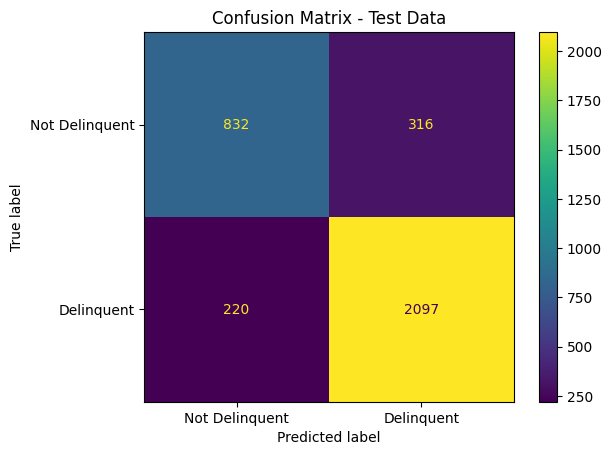

In [16]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Delinquent", "Delinquent"])
disp.plot(values_format="d")
plt.title("Confusion Matrix - Test Data")
plt.show()

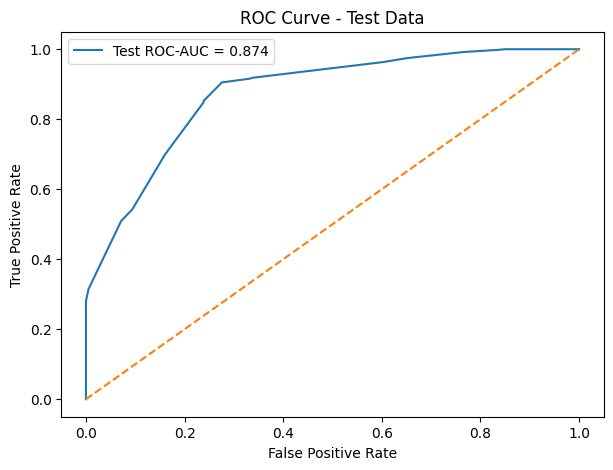

In [17]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Test ROC-AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Data")
plt.legend()
plt.show()

## Feature Importance

In [18]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
17,cat__FICO_>500,0.392573
0,cat__term_36 months,0.333064
3,cat__gender_Male,0.169692
1,cat__term_60 months,0.053815
14,cat__age_20-25,0.041566
13,cat__home_ownership_Rent,0.002971
11,cat__home_ownership_Mortgage,0.002694
4,cat__purpose_Car,0.001864
9,cat__purpose_Wedding,0.000733
7,cat__purpose_Other,0.000532


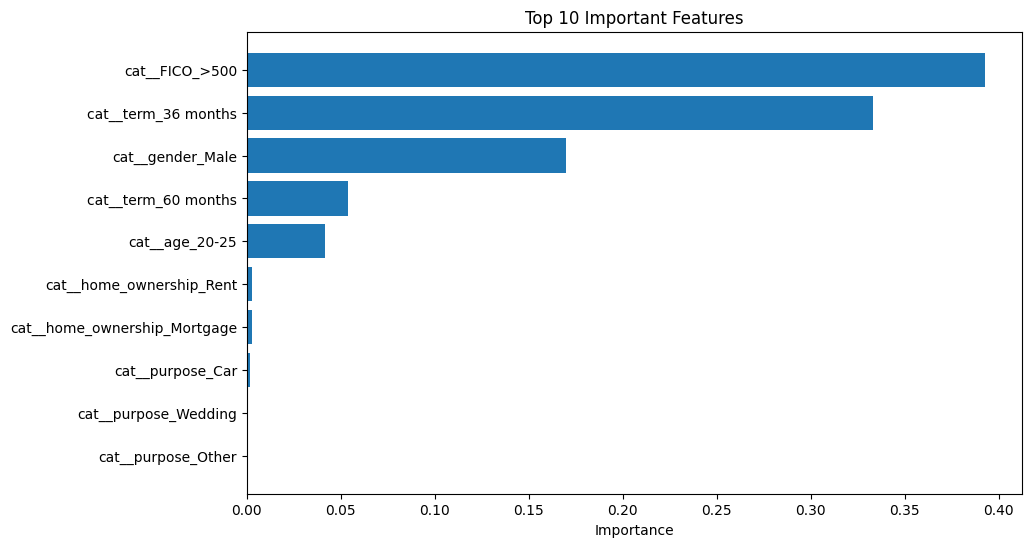

In [19]:
plt.figure(figsize=(10, 6))
top_features = feature_importance_df.head(10).sort_values("Importance")
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.show()

## Decision Tree Visualization

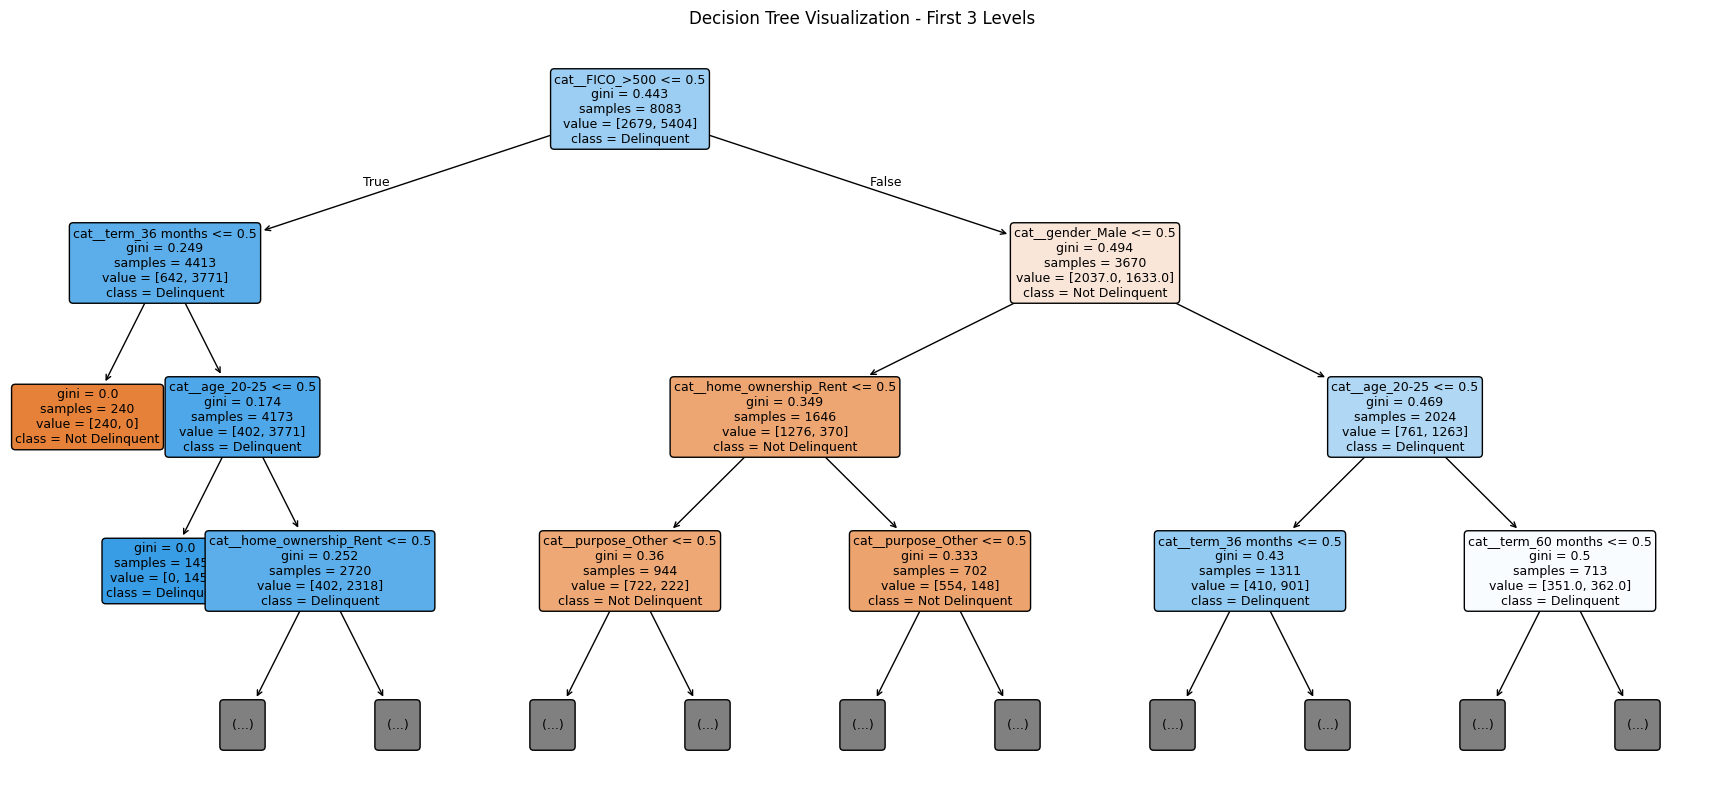

In [20]:
plt.figure(figsize=(22, 10))
plot_tree(
    best_model.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Delinquent", "Delinquent"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Visualization - First 3 Levels")
plt.show()

## Observations

1. The dataset contains **11,548 loan records** and 9 columns.
2. The target variable is `Sdelinquent`, where `1` represents delinquent customers and `0` represents non-delinquent customers.
3. The dataset is moderately imbalanced, with more delinquent records than non-delinquent records.
4. The model achieved approximately **84–85% test accuracy** and approximately **0.87 test ROC-AUC**.
5. The most important predictors include **FICO score**, **loan term**, **gender**, and **age group**.
6. FICO score appears to be the strongest variable in identifying delinquency risk.
7. The model performs well on both training and testing data, which indicates that the regularized decision tree is not heavily overfitting.

## Conclusion

The CART Decision Tree model is suitable for this loan delinquency classification problem. After proper preprocessing, one-hot encoding, train-test splitting, and hyperparameter tuning, the model gives good predictive performance.

The analysis shows that customer credit-related characteristics, especially **FICO score**, along with loan term and demographic variables, are important in predicting delinquency. Financial institutions can use this type of model to identify higher-risk borrowers and support better credit risk monitoring.